<a href="https://colab.research.google.com/github/SulabhSamir94/Weekend_Data_Challenge_CodingWithSubin/blob/main/Prediction_for_car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weekend Data Challenge #07: Predicting Price

**Objective:** Use the `used_cars.csv` file from weekend challenge #06 and create a predictive model from it

## Setup and loading

Improting required libraries and files

In [1]:
# Regular libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importig the data file directly from Kaggle
import kagglehub
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

Using Colab cache for faster access to the 'used-car-price-prediction-dataset' dataset.


In [3]:
# Seting up our dataframe
df = pd.read_csv(path + '/used_cars.csv')# the '/' before the address is equally important
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## Cleaning the data
1. We will pars the values like `'price'` and `'milage'` as they need to be numeric values.
2. We will create columns like `'car_age'`, `'milage_per_year'`, `'brand_tier'`
3. Before creating `'brand_tier'` we would need to adjust the name of _Land Rover_ in `'brand'`

In [4]:
# Parsing 'price' and 'milage'
df['price'] = df['price'].str.replace('$', '', regex = False).str.replace(',', '', regex = False).astype(float)
df['milage'] = df['milage'].str.replace('mi.', '', regex = False).str.replace(',', '', regex = False).astype(float)
# We can print it to check, if error occurs then whatever we did before was not correct
# i.e. the '$', ',' and 'mi' were not present. Which the error we get on rerun
print(df[['price', 'milage']].head(5))

     price   milage
0  10300.0  51000.0
1  38005.0  34742.0
2  54598.0  22372.0
3  15500.0  88900.0
4  34999.0   9835.0


In [5]:
# Correcting the name of Land Rover, which in here is just 'Land'
land_rover_mask = df['brand'] == "Land" # Indicating that there's only "Land" as the name fo the brand
df.loc[land_rover_mask, 'brand'] = "Land Rover" # Correcting the name
# At the same time, the corresponding 'model' columns have 'Rover' written in it.
df.loc[land_rover_mask, 'model'] = df.loc[land_rover_mask, 'model'].str.replace('Rover', '', n = 1, regex = False)


In [6]:
# Creating columns for 'car_age', 'milage_per_year' and 'brand_tier'
df['car_age'] = 2026 - df['model_year'] # Age in terms of 2026
df['milage_per_year'] = df['milage'] / df['car_age'] # Total milage by years used or 'car_age'
# Defining luxury brands
luxury_brands = [ # Defined with the help of AI, by giving it unique values in 'brand' column
    "Acura",
    "Alfa",
    "Aston",
    "Audi",
    "Bentley",
    "BMW",
    "Bugatti",
    "Cadillac",
    "Ferrari",
    "Genesis",
    "INFINITI",
    "Jaguar",
    "Karma",
    "Lamborghini",
    "Land Rover",
    "Lexus",
    "Lincoln",
    "Lotus",
    "Lucid",
    "Maserati",
    "Maybach",
    "McLaren",
    "Mercedes-Benz",
    "Polestar",
    "Porsche",
    "Rolls-Royce",
    "Volvo",
]

# Defining 'brand_tier'
df['brand_tier'] = df['brand'].apply(lambda x: 'Luxury' if x in luxury_brands else 'Non-Luxury')

## Trying to build model


### Encoding

We may need some of the column information to be in numeric values.

In [7]:
# Encoding brand_tier
df['brand_tier_num'] = (df['brand_tier'] == 'Luxury').astype(int)

### Selecting features and target


In [8]:
features = ['car_age', 'milage_per_year', 'brand_tier_num']
X = df[features]
y = df['price']

### Train/test split

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state = 42 )
# The model only ever trains on X_train/ y_train. X_test is held back so we can
# check how the model performs on cars it has never seen, that is the whole point
# of the split.

### Fit the model

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print(dict(zip(features, model.coef_.round(1))))

# Upon printing the coefficients we notice that:
# 'car_age' and 'milage_per_year' both have negative coefficients,
# meaning, 'price' goes down as these values go up
# A positive and high coefficient indicates that for brands that are in
# 'Luxury' category, we do get higher 'price'

{'car_age': np.float64(-2728.3), 'milage_per_year': np.float64(-4.1), 'brand_tier_num': np.float64(16801.2)}


### Predict and evaluate

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# We have MSE of a very high values, which might indicate that the model predictions are off by a large number
# An R-squared of 0.03, means that only 3% of the price variation is explained by the model.

Mean Squared Error: 19741632727.12
R-squared: 0.03


In [20]:
print(y_pred.max())

105493.69918752417


### Visualization
Scatter plot


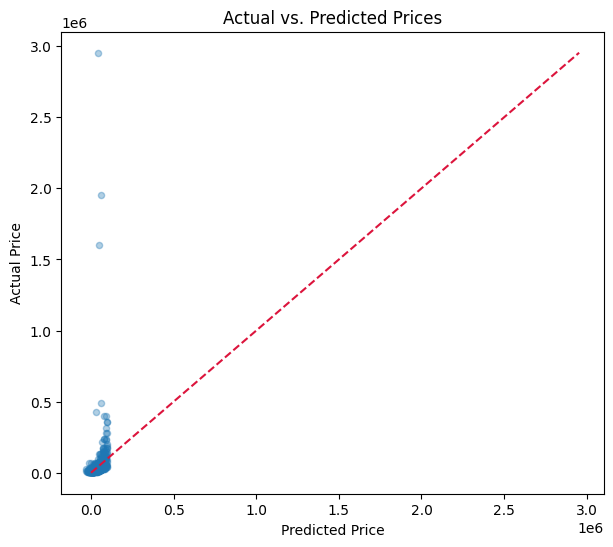

In [12]:
# It would be helpful to see how the model performs against actual values
plt.figure(figsize = (7, 6))
plt.scatter(y_pred, y_test, alpha = 0.35, s = 20)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color = 'crimson', linestyle = '--')
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs. Predicted Prices')
plt.show()

## As it seems like the model is quite bad, lets try to look for things that might have gone wrong.

In [13]:
# Lets check the summary statistics for the core variables
print(df[['price', 'car_age', 'milage_per_year']].describe())

              price      car_age  milage_per_year
count  4.009000e+03  4009.000000      4009.000000
mean   4.455319e+04    10.484410      5993.281538
std    7.871064e+04     6.104816      3782.668958
min    2.000000e+03     2.000000        25.000000
25%    1.720000e+04     6.000000      3189.296296
50%    3.100000e+04     9.000000      5530.800000
75%    4.999000e+04    14.000000      8187.777778
max    2.954083e+06    52.000000     39900.000000


In [14]:
# Lets see if the price or features have any missing values or weird types
print(df[['price', 'car_age', 'milage_per_year', 'brand_tier_num']].isnull().sum())

price              0
car_age            0
milage_per_year    0
brand_tier_num     0
dtype: int64


While there doesn't seem to be much problem in here, we can suspect that there's an issue with the way in which we have set the `'car_age'` using 2026 as reference year.
Lets redo things by setting the year as 2023, which was the date of pulish (and last update) of the dataset.

In [15]:
# Seting 'car_age' to be referenced by the year 2023
df['car_age'] = 2023 - df['model_year']
df['car_age'] = df['car_age'].replace(0, 1)
df['milage_per_year'] = df['milage'] / df['car_age']

In [16]:
# Lets write the functions for making the model again
# Defining our response variables and explanatory variables
features = ['car_age', 'milage_per_year', 'brand_tier_num']
X = df[features]
y = df['price']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state = 42 )

# Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print(dict(zip(features, model.coef_.round(1))))

# Predict and Evaluate
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")



{'car_age': np.float64(-3624.3), 'milage_per_year': np.float64(-2.0), 'brand_tier_num': np.float64(16460.0)}
Mean Squared Error: 20012715737.58
R-squared: 0.02


Replacing the values doesn't result in having a better version of the misfit model.

## Lets make use of AI to do it


Rows remaining after cleaning/filtering: 3881

Model Coefficients (on Log Scale):
{'car_age': np.float64(-0.095), 'mileage_per_year': np.float64(-0.0), 'brand_tier_num': np.float64(0.221)}

Corrected Evaluation Metrics (in Real Dollars):
RMSE: $19,547
R-squared: 0.42


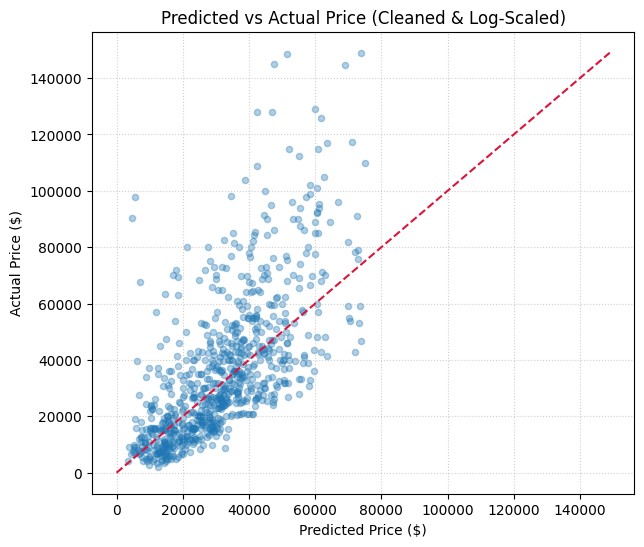

(3881, 17)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df['mileage_per_year'] = df['milage'] / df['car_age']
# --- DATA SANITY & CLEANING SAFEGUARDS ---
# Force core columns to numeric, forcing errors to NaN just in case symbols lingered
df['price'] = pd.to_numeric(df['price'].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce')
df['car_age'] = pd.to_numeric(df['car_age'], errors='coerce')
df['mileage_per_year'] = pd.to_numeric(df['mileage_per_year'], errors='coerce')

# Drop any rows where these essential columns are missing after coercion
df = df.dropna(subset=['price', 'car_age', 'mileage_per_year', 'brand_tier'])

# Remove extreme outliers that ruin regression (e.g., free cars, typo prices > $150k, or negative ages)
df = df[(df['price'] > 500) & (df['price'] < 150000)]
df = df[(df['car_age'] >= 0) & (df['car_age'] <= 30)]

print(f"Rows remaining after cleaning/filtering: {len(df)}")

# 2. Encode brand_tier as a number (0/1)[cite: 1, 2]
df["brand_tier_num"] = (df["brand_tier"].str.strip().str.lower() == "luxury").astype(int)

# 3. Pick features[cite: 1, 2]
features = ["car_age", "mileage_per_year", "brand_tier_num"]
X = df[features]

# Try log-transforming price to fix the billion-dollar MSE / low R-squared issue
# (Linear regression handles log(price) much better due to right-skew)
y = np.log(df["price"])

# 4. Train/test split[cite: 2]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Fit model[cite: 2]
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Coefficients (on Log Scale):")
print(dict(zip(features, model.coef_.round(3))) )

# 6. Predict[cite: 2]
y_pred_log = model.predict(X_test)

# Convert predictions and actuals back from log scale to real dollars for evaluation
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_log)

# 7. Evaluate with real metrics[cite: 2]
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\nCorrected Evaluation Metrics (in Real Dollars):")
print(f"RMSE: ${rmse:,.0f}")
print(f"R-squared: {r2:.2f}")

# 8. Visualization: predicted price vs. actual price[cite: 3]
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_actual, y_test_actual, alpha=0.35, s=20)
lims = [0, max(y_test_actual.max(), y_pred_actual.max())]
plt.plot(lims, lims, color="crimson", linestyle="--")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Actual Price ($)")
plt.title("Predicted vs Actual Price (Cleaned & Log-Scaled)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

print(df.shape)

In [26]:
# Bonus Analysis: Inspecting the biggest errors
results_df = X_test.copy()
results_df['actual_price'] = y_test_actual
results_df['predicted_price'] = y_pred_actual
results_df['error'] = results_df['predicted_price'] - results_df['actual_price']
results_df['abs_error'] = results_df['error'].abs()

# Sort by largest absolute error to find where the model is most wrong	op_errors = results_df.sort_values(by='abs_error', ascending=False).head(10)
print("\nTop 10 Largest Prediction Errors:")
print(top_errors[['actual_price', 'predicted_price', 'error']])
print(df[df.index.isin(top_errors.index)])


Top 10 Largest Prediction Errors:
      actual_price  predicted_price         error
2390      145000.0     47593.022478 -97406.977522
2380      148500.0     51409.304351 -97090.695649
2837       97993.0      5625.958470 -92367.041530
2303       90200.0      4564.010091 -85635.989909
432       127899.0     42542.264693 -85356.735307
3240      128000.0     46933.111227 -81066.888773
306       144664.0     69081.309917 -75582.690083
3706      149000.0     73799.488094 -75200.511906
1182      128900.0     59946.048362 -68953.951638
226       108900.0     42562.152929 -66337.847071
              brand                 model  model_year   milage fuel_type  \
226   Mercedes-Benz         AMG G 63 Base        2018  41000.0  Gasoline   
306   Mercedes-Benz     AMG GLS 63 4MATIC        2022   4102.0    Hybrid   
432   Mercedes-Benz  G-Class G 550 4MATIC        2019  47850.0  Gasoline   
1182  Mercedes-Benz              AMG GT C        2020   6600.0  Gasoline   
2303          Acura              NS